# Verification: Full Fine-tune, 3 Epochs, 113 Classes, fp16

**Purpose:** Get exact reference numbers for the canonical 113-class split.
This is NOT a student notebook — it's an instructor verification run.

Expected time: ~30 minutes on Kaggle T4.

In [1]:
import sys
import subprocess
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "transformers>=4.53", "datasets", "accelerate", "scikit-learn",
    "matplotlib", "pandas", "tqdm",
])

0

In [2]:
import os
import time
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score

# Clone course repo for data utilities
REPO_PATH = Path("../..").resolve()
if not (REPO_PATH / "utils" / "data_utils.py").exists():
    REPO_PATH = Path("/tmp/course")
    if not REPO_PATH.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
            "https://github.com/earino/applied-deep-learning.git", str(REPO_PATH)])
sys.path.insert(0, str(REPO_PATH))

from utils.data_utils import (
    load_course_data, LABEL_LIST, NUM_LABELS, LABEL_TO_ID, ID_TO_LABEL, MAX_LENGTH,
)

Cloning into '/tmp/course'...


## Configuration

In [3]:
MODEL_NAME = "answerdotai/ModernBERT-base"
BATCH_SIZE = 32
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_FRACTION = 0.10
SEED = 42

print(f"Config: {NUM_EPOCHS} epochs, lr={LEARNING_RATE}, bs={BATCH_SIZE}")

Config: 3 epochs, lr=2e-05, bs=32


## Setup

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    cc = torch.cuda.get_device_capability()
    AMP_DTYPE = torch.bfloat16 if cc[0] >= 8 else torch.float16
else:
    AMP_DTYPE = torch.float32

print(f"Device: {device}")
print(f"AMP dtype: {AMP_DTYPE}")

Device: cuda
AMP dtype: torch.float16


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_ds, val_ds, test_ds = load_course_data(tokenizer=tokenizer, max_length=MAX_LENGTH)
print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/606 [00:00<?, ?B/s]

...

Filter:   0%|          | 0/21439 [00:00<?, ? examples/s]

Map:   0%|          | 0/57846 [00:00<?, ? examples/s]

Map:   0%|          | 0/6430 [00:00<?, ? examples/s]

Map:   0%|          | 0/21432 [00:00<?, ? examples/s]

Train: 57,846  Val: 6,430  Test: 21,432


In [6]:
class ComplaintDataset(Dataset):
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset
    def __len__(self):
        return len(self.hf_dataset)
    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(item["label"], dtype=torch.long),
        }

train_loader = DataLoader(ComplaintDataset(train_ds), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ComplaintDataset(val_ds), batch_size=BATCH_SIZE, shuffle=False)

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, attn_implementation="sdpa",
    id2label=ID_TO_LABEL, label2id=LABEL_TO_ID,
)
model = model.to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 149,691,761


In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_FRACTION)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return max(0.0, float(total_steps - current_step) / float(max(1, total_steps - warmup_steps)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
use_scaler = (AMP_DTYPE == torch.float16)
scaler = GradScaler("cuda", enabled=use_scaler)

print(f"Total steps: {total_steps}, warmup: {warmup_steps}")

Total steps: 5424, warmup: 542


## Train + validate each epoch

In [9]:
results_per_epoch = []
step_losses = []
training_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_start = time.time()
    running_loss = 0.0
    n_samples = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")
    for batch in progress:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        step_loss = loss.item()
        step_losses.append(step_loss)
        running_loss += step_loss * labels.size(0)
        n_samples += labels.size(0)

    epoch_time = time.time() - epoch_start
    epoch_loss = running_loss / n_samples

    # Validate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Val {epoch}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    val_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    zero_f1 = int(sum(1 for f in per_class_f1 if f == 0.0))

    result = {
        "epoch": epoch,
        "train_loss": round(epoch_loss, 4),
        "val_accuracy": round(val_acc, 4),
        "val_macro_f1": round(val_macro_f1, 4),
        "val_weighted_f1": round(val_weighted_f1, 4),
        "zero_f1_classes": zero_f1,
        "epoch_time_sec": round(epoch_time, 0),
    }
    results_per_epoch.append(result)
    print(f"  Epoch {epoch}: loss={epoch_loss:.4f}, acc={val_acc:.4f}, "
          f"macro_f1={val_macro_f1:.4f}, zero_f1={zero_f1}, time={epoch_time:.0f}s")

total_time = time.time() - training_start
print(f"\nTotal training time: {total_time:.0f}s ({total_time/60:.1f} min)")

Epoch 1/3:   0%|          | 0/1808 [00:00<?, ?it/s]

W0405 15:19:58.376000 55 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Val 1:   0%|          | 0/201 [00:00<?, ?it/s]

  Epoch 1: loss=2.2586, acc=0.5278, macro_f1=0.1397, zero_f1=68, time=629s


Epoch 2/3:   0%|          | 0/1808 [00:00<?, ?it/s]

Val 2:   0%|          | 0/201 [00:00<?, ?it/s]

  Epoch 2: loss=1.5382, acc=0.5580, macro_f1=0.1982, zero_f1=48, time=624s


Epoch 3/3:   0%|          | 0/1808 [00:00<?, ?it/s]

Val 3:   0%|          | 0/201 [00:00<?, ?it/s]

  Epoch 3: loss=1.1814, acc=0.5659, macro_f1=0.2085, zero_f1=46, time=623s

Total training time: 1948s (32.5 min)


## Results summary

In [10]:
df = pd.DataFrame(results_per_epoch)
print(df.to_string(index=False))

# Best epoch by macro F1
best = max(results_per_epoch, key=lambda r: r["val_macro_f1"])
print(f"\nBest epoch by macro F1: epoch {best['epoch']}")
print(f"  Accuracy:     {best['val_accuracy']}")
print(f"  Macro F1:     {best['val_macro_f1']}")
print(f"  Weighted F1:  {best['val_weighted_f1']}")
print(f"  Zero-F1 classes: {best['zero_f1_classes']}/{NUM_LABELS}")

 epoch  train_loss  val_accuracy  val_macro_f1  val_weighted_f1  zero_f1_classes  epoch_time_sec
     1      2.2586        0.5278        0.1397           0.4696               68           629.0
     2      1.5382        0.5580        0.1982           0.5222               48           624.0
     3      1.1814        0.5659        0.2085           0.5378               46           623.0

Best epoch by macro F1: epoch 3
  Accuracy:     0.5659
  Macro F1:     0.2085
  Weighted F1:  0.5378
  Zero-F1 classes: 46/113


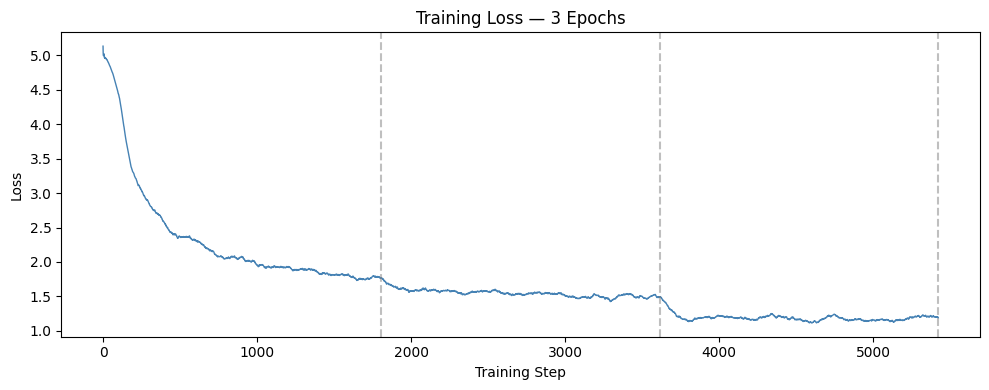

In [11]:
# Learning curve
fig, ax = plt.subplots(figsize=(10, 4))
window = max(1, len(step_losses) // 50)
smoothed = pd.Series(step_losses).rolling(window, min_periods=1).mean()
ax.plot(smoothed, color="steelblue", linewidth=1)
ax.set_xlabel("Training Step")
ax.set_ylabel("Loss")
ax.set_title(f"Training Loss — {NUM_EPOCHS} Epochs")
for e in range(1, NUM_EPOCHS + 1):
    ax.axvline(e * len(train_loader), color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# Save results
output = {
    "model": MODEL_NAME,
    "num_classes": NUM_LABELS,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "amp_dtype": str(AMP_DTYPE),
    "total_time_sec": round(total_time, 0),
    "per_epoch": results_per_epoch,
    "best_epoch": best,
}

with open("full_finetune_3epoch_results.json", "w") as f:
    json.dump(output, f, indent=2)
print("Saved full_finetune_3epoch_results.json")

Saved full_finetune_3epoch_results.json
